# scikit-learn: Basics to Expert

A single, self-contained tour of **scikit-learn** — from your first `fit`/`predict` to custom estimators, leakage traps, threshold tuning, and calibration. Everything runs on CPU in seconds using built-in datasets (no downloads).

## Table of contents

1. [The big idea: the Estimator API](#1)
2. [Datasets: loaders and synthetic generators](#2)
3. [Train/test split done right](#3)
4. [Preprocessing: scalers, encoders, imputers](#4)
5. [Pipelines & ColumnTransformer (the #1 idiom)](#5)
6. [Classification model tour](#6)
7. [Regression, regularization & the bias-variance tradeoff](#7)
8. [Model evaluation beyond accuracy](#8)
9. [Cross-validation](#9)
10. [Hyperparameter tuning: Grid, Random, Halving](#10)
11. [Ensembles: Voting, Bagging, Stacking](#11)
12. [Clustering](#12)
13. [Dimensionality reduction: PCA & t-SNE](#13)
14. [Feature selection & importance (and a leakage trap)](#14)
15. [Text features](#15)
16. [Expert: custom transformers & estimators](#16)
17. [Expert: imbalance, decision thresholds & calibration](#17)
18. [Expert: learning & validation curves](#18)
19. [Model persistence & production notes](#19)
20. [Gotchas & cheat sheet](#20)

> Written for scikit-learn ≥ 1.5 (run below to check your version).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
import sklearn

print("scikit-learn:", sklearn.__version__)
print("numpy:", np.__version__, "| pandas:", pd.__version__)

# One fixed, colorblind-safe categorical palette used throughout the notebook
# (assigned in this fixed order, never re-shuffled per chart).
PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
           "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
GRAY = "#898781"

plt.rcParams.update({
    "axes.prop_cycle": cycler(color=PALETTE),
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e", "axes.titlecolor": "#0b0b0b",
    "xtick.color": GRAY, "ytick.color": GRAY,
    "figure.dpi": 100, "figure.facecolor": "white",
})

rng = np.random.default_rng(42)  # modern NumPy random generator for our own data

scikit-learn: 1.7.2
numpy: 2.3.1 | pandas: 2.3.0


<a id="1"></a>
## 1. The big idea: the Estimator API

scikit-learn's superpower is that **every model, preprocessor, and feature selector shares one tiny interface**:

| Method | Who has it | What it does |
|---|---|---|
| `fit(X, y)` | everything | learn from data; returns `self` |
| `predict(X)` | models | predict labels / values |
| `transform(X)` | preprocessors | rewrite features (scale, encode, reduce…) |
| `fit_transform(X)` | preprocessors | `fit` then `transform` in one call |
| `predict_proba(X)` | many classifiers | class probabilities |
| `score(X, y)` | models | default metric (accuracy / $R^2$) |

Two conventions to internalize:

- **`X` is always 2-D** — shape `(n_samples, n_features)` — even for one feature (`X.reshape(-1, 1)`). **`y` is 1-D**.
- **Learned attributes end with an underscore** (`coef_`, `classes_`, `mean_`). If you see the underscore, the estimator has been fitted. Constructor arguments (hyperparameters) never end in `_`.

Because everything speaks this interface, you can swap a k-NN for a gradient-boosted ensemble by changing one line — and compose anything into pipelines (§5).

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris(as_frame=True)          # Bunch: dict-like with .data, .target, .frame
X, y = iris.data, iris.target            # X: DataFrame (150, 4), y: Series (150,)
print(X.shape, y.shape)
X.head(3)

(150, 4) (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [3]:
# The canonical 4 lines of scikit-learn:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

knn = KNeighborsClassifier(n_neighbors=5)   # 1. instantiate (hyperparameters here)
knn.fit(X_train, y_train)                   # 2. learn from TRAINING data only
y_pred = knn.predict(X_test)                # 3. predict on unseen data
print("test accuracy:", knn.score(X_test, y_test))   # 4. evaluate
print("first 10 predictions:", y_pred[:10])
print("classes_:", knn.classes_)            # trailing underscore => learned attribute

test accuracy: 0.9736842105263158
first 10 predictions: [0 1 1 1 0 1 2 2 2 2]
classes_: [0 1 2]


In [4]:
# predict_proba gives calibratable class probabilities (columns follow classes_)
proba = knn.predict_proba(X_test[:5])
pd.DataFrame(proba, columns=iris.target_names).round(2)

,setosa,versicolor,virginica
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0


**Gotcha:** calling `predict` before `fit` raises `NotFittedError`. And `fit` always **resets** the estimator — refitting on new data forgets the old fit entirely (unless the model supports `partial_fit` / `warm_start`, an expert topic we touch in §19).

<a id="2"></a>
## 2. Datasets: loaders and synthetic generators

Three families in `sklearn.datasets`:

- **`load_*`** — small classics shipped with the library (no download): `load_iris`, `load_digits`, `load_wine`, `load_breast_cancer`, `load_diabetes`.
- **`fetch_*`** — larger real datasets downloaded on first use (`fetch_california_housing`, `fetch_20newsgroups`). We avoid these here to stay offline.
- **`make_*`** — synthetic generators, invaluable for testing intuition: `make_classification`, `make_regression`, `make_moons`, `make_blobs`, `make_circles`.

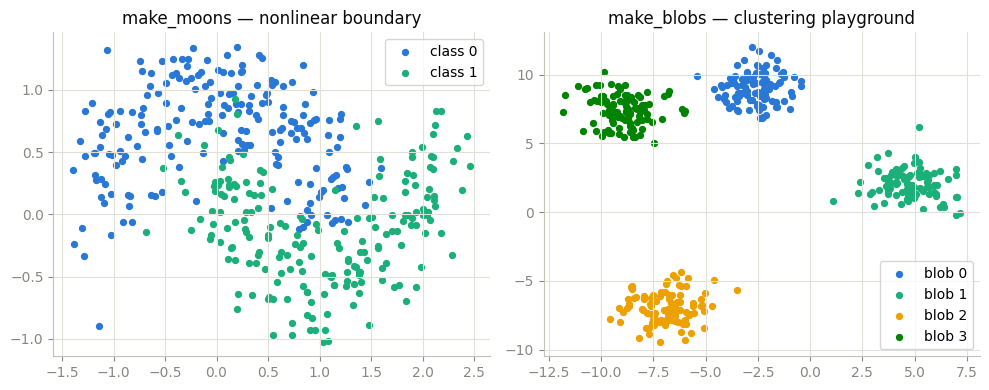

In [5]:
from sklearn.datasets import make_moons, make_blobs, make_classification

X_moons, y_moons = make_moons(n_samples=400, noise=0.25, random_state=42)
X_blobs, y_blobs = make_blobs(n_samples=400, centers=4, cluster_std=1.1, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for cls in np.unique(y_moons):
    m = y_moons == cls
    axes[0].scatter(X_moons[m, 0], X_moons[m, 1], s=18, color=PALETTE[cls],
                    label=f"class {cls}")
axes[0].set_title("make_moons — nonlinear boundary")
axes[0].legend()
for cls in np.unique(y_blobs):
    m = y_blobs == cls
    axes[1].scatter(X_blobs[m, 0], X_blobs[m, 1], s=18, color=PALETTE[cls],
                    label=f"blob {cls}")
axes[1].set_title("make_blobs — clustering playground")
axes[1].legend()
plt.tight_layout(); plt.show()

In [6]:
# make_classification lets you dial difficulty: informative vs redundant vs noise features,
# class separation, imbalance... We'll reuse it a lot.
X_syn, y_syn = make_classification(
    n_samples=1000, n_features=20, n_informative=5, n_redundant=5,
    weights=[0.7, 0.3], flip_y=0.02, class_sep=0.9, random_state=42)
print(X_syn.shape, "| class balance:", np.bincount(y_syn))

(1000, 20) | class balance: [693 307]


<a id="3"></a>
## 3. Train/test split done right

The test set exists to estimate **generalization** — performance on data the model has *never* influenced. Three flags matter:

- **`stratify=y`** (classification): keeps class proportions identical in both splits. Without it, a rare class can end up under-represented in the test set purely by chance.
- **`random_state=...`**: makes the split reproducible. Any number works; being *consistent* is what matters.
- **`test_size`**: 0.2–0.25 is the usual default for small/medium data.

**The golden rule (memorize this):** *anything learned from data — scaling means, vocabulary, selected features, imputation values — must be learned from the training set only.* Violating it is called **data leakage** and silently inflates your scores. §14 demonstrates how badly.

In [7]:
y_imb = np.array([0]*95 + [1]*5)          # 5% positive class
X_dummy = np.zeros((100, 1))

_, _, _, yte_plain = train_test_split(X_dummy, y_imb, test_size=0.2, random_state=7)
_, _, _, yte_strat = train_test_split(X_dummy, y_imb, test_size=0.2, random_state=7,
                                      stratify=y_imb)
print("positives in test w/o stratify:", yte_plain.sum(), "/ 20")
print("positives in test with stratify:", yte_strat.sum(), "/ 20")

positives in test w/o stratify: 0 / 20
positives in test with stratify: 1 / 20


<a id="4"></a>
## 4. Preprocessing: scalers, encoders, imputers

Many models (SVMs, k-NN, logistic regression, neural nets, PCA, k-means) assume features live on **comparable scales** — a feature in the thousands will dominate one in the decimals. Tree-based models are the notable exception (splits are scale-invariant).

| Transformer | What it does | When |
|---|---|---|
| `StandardScaler` | mean 0, std 1 | default choice |
| `MinMaxScaler` | squashes to [0, 1] | bounded inputs (images, NN) |
| `RobustScaler` | median/IQR based | data with outliers |
| `PowerTransformer` / `QuantileTransformer` | reshape the *distribution* toward Gaussian/uniform | heavily skewed features |

The crucial pattern: **`fit` on train, `transform` both** — the test set must be scaled with the *training* statistics.

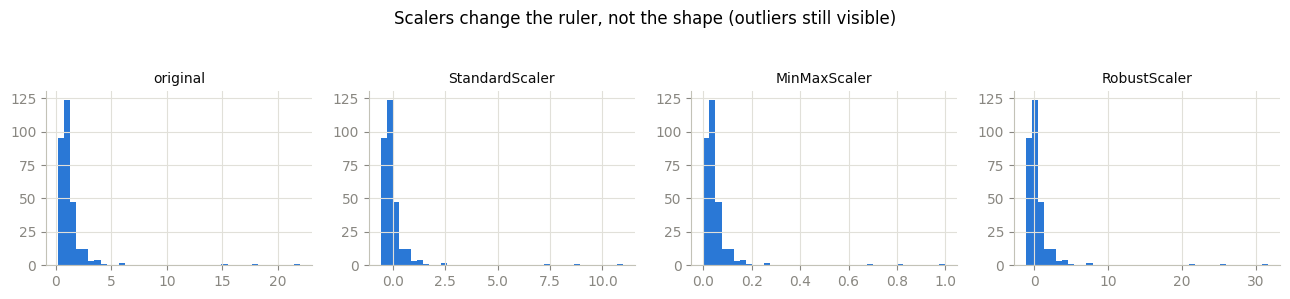

In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Skewed feature with outliers
x_skew = np.concatenate([rng.lognormal(0, 0.6, 300), [15, 18, 22]]).reshape(-1, 1)

scalers = {"original": None, "StandardScaler": StandardScaler(),
           "MinMaxScaler": MinMaxScaler(), "RobustScaler": RobustScaler()}
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8))
for ax, (name, sc) in zip(axes, scalers.items()):
    vals = x_skew if sc is None else sc.fit_transform(x_skew)
    ax.hist(vals, bins=40, color=PALETTE[0])
    ax.set_title(name, fontsize=10)
plt.suptitle("Scalers change the ruler, not the shape (outliers still visible)", y=1.05)
plt.tight_layout(); plt.show()

In [9]:
# The fit-on-train / transform-both pattern:
Xtr = rng.normal(10, 3, (200, 2))
Xte = rng.normal(10, 3, (50, 2))

scaler = StandardScaler().fit(Xtr)        # statistics learned from TRAIN only
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)
print("learned mean_:", scaler.mean_.round(2), " scale_:", scaler.scale_.round(2))
print("train scaled mean:", Xtr_s.mean(axis=0).round(3))
print("test  scaled mean:", Xte_s.mean(axis=0).round(3), " (≈0 but not exactly — correct!)")

learned mean_: [9.95 9.83]  scale_: [3.1  3.03]
train scaled mean: [ 0. -0.]
test  scaled mean: [-0.025  0.173]  (≈0 but not exactly — correct!)


### Encoding categorical features

Models need numbers. Two main tools:

- **`OneHotEncoder`** — one binary column per category. Safe default for *nominal* (unordered) categories. `handle_unknown="ignore"` keeps prediction from crashing on unseen categories.
- **`OrdinalEncoder`** — one integer column. Correct only when categories have a *true order* (S < M < L), or for tree models (which don't read magnitude as distance the way linear models do).

**Gotcha:** using `OrdinalEncoder` on nominal data with a linear model invents a fake ordering (`paris=2 > london=1`?) that the model will happily exploit.

In [10]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

city = pd.DataFrame({"city": ["paris", "tokyo", "paris", "delhi", "tokyo"]})

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
onehot = ohe.fit_transform(city)
print(pd.DataFrame(onehot, columns=ohe.get_feature_names_out()))

size = pd.DataFrame({"size": ["S", "L", "M", "S", "XL"]})
oe = OrdinalEncoder(categories=[["S", "M", "L", "XL"]])   # explicit true order
print("\nordinal:", oe.fit_transform(size).ravel())

   city_delhi  city_paris  city_tokyo
0         0.0         1.0         0.0
1         0.0         0.0         1.0
2         0.0         1.0         0.0
3         1.0         0.0         0.0
4         0.0         0.0         1.0

ordinal: [0. 2. 1. 0. 3.]


### Missing values

scikit-learn estimators reject `NaN` (with a few exceptions like `HistGradientBoosting*`, which handles them natively). Impute first:

- `SimpleImputer` — mean / median / most_frequent / constant.
- `KNNImputer` — fill from the k nearest complete rows (uses feature similarity).
- Expert trick: `SimpleImputer(add_indicator=True)` appends a "was missing" flag column — missingness itself is often predictive.

In [11]:
from sklearn.impute import SimpleImputer, KNNImputer

Xm = np.array([[1.0, 2.0], [np.nan, 3.0], [7.0, 6.0], [4.0, np.nan]])
print("median imputed:\n", SimpleImputer(strategy="median").fit_transform(Xm))
print("\nKNN imputed:\n", KNNImputer(n_neighbors=2).fit_transform(Xm))
print("\nwith missing-indicator:\n",
      SimpleImputer(strategy="mean", add_indicator=True).fit_transform(Xm))

median imputed:
 [[1. 2.]
 [4. 3.]
 [7. 6.]
 [4. 3.]]

KNN imputed:
 [[1. 2.]
 [4. 3.]
 [7. 6.]
 [4. 4.]]

with missing-indicator:
 [[1.         2.         0.         0.        ]
 [4.         3.         1.         0.        ]
 [7.         6.         0.         0.        ]
 [4.         3.66666667 0.         1.        ]]


In [12]:
# PolynomialFeatures: manufacture interactions & powers for linear models
from sklearn.preprocessing import PolynomialFeatures

Xp = np.array([[2, 3]])
poly = PolynomialFeatures(degree=2, include_bias=False)
print(poly.fit_transform(Xp))                 # [x1, x2, x1², x1·x2, x2²]
print(poly.get_feature_names_out(["x1", "x2"]))

[[2. 3. 4. 6. 9.]]
['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']


<a id="5"></a>
## 5. Pipelines & ColumnTransformer — the #1 idiom

A `Pipeline` chains transformers and ends in a model. **This is not a convenience — it's the leakage-proofing mechanism**: when a pipeline is cross-validated or grid-searched, every preprocessing step is re-fitted *inside* each training fold, exactly as it should be.

```
pipe.fit(X, y)      ->  scaler.fit_transform(X) -> model.fit(...)
pipe.predict(X_new) ->  scaler.transform(X_new) -> model.predict(...)
```

Steps are named (`make_pipeline` auto-names them from the class, lowercased) — those names become hyperparameter prefixes in grid search: `svc__C` (§10).

In [13]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target        # 569 tumors, 30 features, binary target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.25, random_state=42, stratify=yc)

pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0))
pipe.fit(Xc_train, yc_train)
print("steps:", list(pipe.named_steps))
print("accuracy with scaling   :", round(pipe.score(Xc_test, yc_test), 3))
print("accuracy without scaling:", round(SVC().fit(Xc_train, yc_train).score(Xc_test, yc_test), 3))

steps:

 ['standardscaler', 'svc']
accuracy with scaling   : 0.979


accuracy without scaling: 0.923


In [14]:
# Pipelines render as interactive diagrams in notebooks — inspect any step via named_steps
pipe.named_steps["standardscaler"].mean_[:3]   # fitted internals are reachable
pipe

,steps,"[('standardscaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


### ColumnTransformer: different preprocessing per column

Real tables mix numeric and categorical columns; `ColumnTransformer` routes each subset through its own sub-pipeline and concatenates the results. Combined with a `Pipeline`, this is the standard skeleton for **any tabular ML project**.

In [15]:
# A realistic messy table: numeric columns with NaNs + categorical columns
n = 400
df = pd.DataFrame({
    "age":   np.where(rng.random(n) < 0.1, np.nan, rng.normal(38, 12, n)).round(1),
    "fare":  rng.lognormal(3, 0.8, n).round(2),
    "sex":   rng.choice(["male", "female"], n),
    "port":  rng.choice(["S", "C", "Q"], n, p=[0.7, 0.2, 0.1]),
})
# target loosely depends on sex + fare + noise
logit = (df["sex"] == "female") * 1.6 + np.log(df["fare"]) * 0.4 - 2 + rng.normal(0, 1, n)
df["survived"] = (logit > 0).astype(int)
df.head()

,age,fare,sex,port,survived
0,61.2,27.18,male,S,0
1,61.5,28.85,female,S,1
2,23.3,25.96,female,S,1
3,26.9,24.31,male,S,0
4,55.8,70.97,female,S,1


In [16]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LogisticRegression

numeric = make_column_selector(dtype_include=np.number)     # picks columns by dtype
categorical = make_column_selector(dtype_include=object)

preprocess = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), categorical),
])

model = Pipeline([("prep", preprocess),
                  ("clf", LogisticRegression(max_iter=1000))])

Xd, yd = df.drop(columns="survived"), df["survived"]
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.25,
                                              random_state=42, stratify=yd)
model.fit(Xd_tr, yd_tr)
print("accuracy:", round(model.score(Xd_te, yd_te), 3))
print("output feature names:", model.named_steps["prep"].get_feature_names_out())

accuracy: 0.8
output feature names: ['num__age' 'num__fare' 'cat__sex_female' 'cat__sex_male' 'cat__port_C'
 'cat__port_Q' 'cat__port_S']


In [17]:
# set_output: make transformers return labeled DataFrames instead of bare arrays
sc = StandardScaler().set_output(transform="pandas")
sc.fit_transform(Xd_tr[["age", "fare"]].fillna(0)).head(3)

,age,fare
108,0.736723,-0.061979
155,0.193929,0.747733
343,-0.985243,-0.697869


<a id="6"></a>
## 6. Classification model tour

The families you'll actually use, and their personalities:

| Model | Boundary | Scaling needed? | Personality |
|---|---|---|---|
| `LogisticRegression` | linear | yes | fast, interpretable coefficients, great baseline |
| `KNeighborsClassifier` | local/flexible | **yes** | no training, slow predict, curse of dimensionality |
| `SVC` (RBF) | smooth nonlinear | **yes** | strong on small/medium data; `C`↑ = less regularization, `gamma`↑ = wigglier |
| `DecisionTreeClassifier` | axis-aligned rectangles | no | interpretable, overfits alone |
| `RandomForestClassifier` | ensemble of trees | no | robust default, hard to badly misuse |
| `HistGradientBoostingClassifier` | boosted trees | no | usually **the strongest tabular model**; handles NaN natively |
| `GaussianNB` | quadratic-ish | no | ultra fast, surprisingly decent, badly calibrated (§17) |

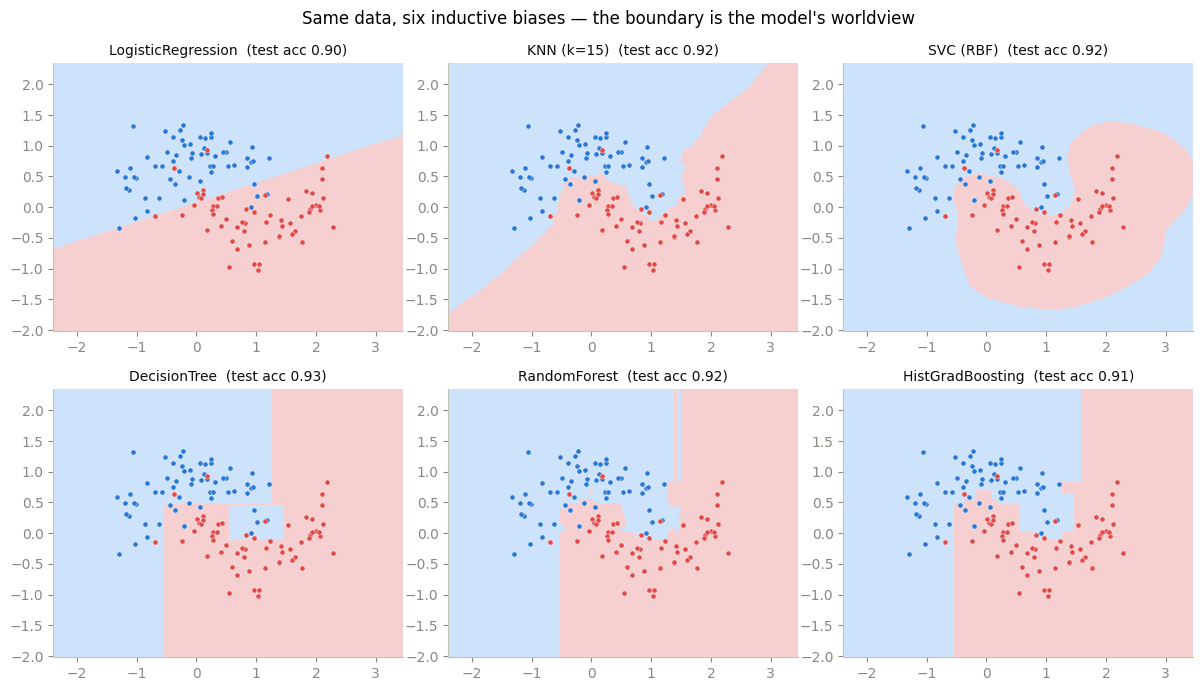

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import ListedColormap

models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression()),
    "KNN (k=15)":         make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
    "SVC (RBF)":          make_pipeline(StandardScaler(), SVC(gamma=2, C=1)),
    "DecisionTree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "RandomForest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "HistGradBoosting":   HistGradientBoostingClassifier(random_state=42),
}

Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_moons, y_moons, test_size=0.3,
                                              random_state=42, stratify=y_moons)
region_cmap = ListedColormap(["#cde2fb", "#f6d0d0"])   # pale tints of the class hues

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (name, clf) in zip(axes.ravel(), models.items()):
    clf.fit(Xm_tr, ym_tr)
    DecisionBoundaryDisplay.from_estimator(clf, X_moons, response_method="predict",
                                           cmap=region_cmap, ax=ax, grid_resolution=200)
    for cls, color in [(0, PALETTE[0]), (1, PALETTE[5])]:
        m = ym_te == cls
        ax.scatter(Xm_te[m, 0], Xm_te[m, 1], s=14, color=color, edgecolor="white",
                   linewidth=0.3)
    ax.set_title(f"{name}  (test acc {clf.score(Xm_te, ym_te):.2f})", fontsize=10)
    ax.grid(False)
plt.suptitle("Same data, six inductive biases — the boundary is the model's worldview")
plt.tight_layout(); plt.show()

Read those boundaries: logistic regression can only draw a line; the tree draws rectangles; RBF-SVM draws smooth blobs; forests/boosting draw flexible-but-jagged shapes. **Model choice = choosing which kinds of mistakes you'd rather make.**

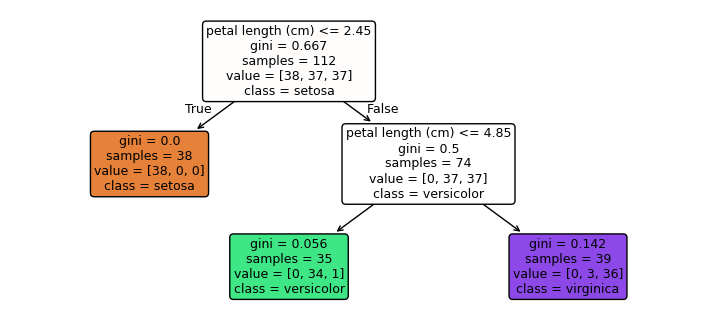

In [19]:
# Trees are the one family you can literally read:
from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_train, y_train)
plt.figure(figsize=(9, 4))
plot_tree(tree, feature_names=iris.feature_names, class_names=list(iris.target_names),
          filled=True, rounded=True, fontsize=9)
plt.show()

In [20]:
# Honest comparison on a real dataset requires cross-validation (§9), not a single split:
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_wine

wine = load_wine()
rows = []
for name, clf in models.items():
    scores = cross_val_score(clf, wine.data, wine.target, cv=5)
    rows.append({"model": name, "mean_acc": scores.mean(), "std": scores.std()})
res = pd.DataFrame(rows).sort_values("mean_acc", ascending=False).reset_index(drop=True)
res.round(3)

,model,mean_acc,std
0,LogisticRegression,0.983,0.014
1,RandomForest,0.972,0.018
2,KNN (k=15),0.955,0.028
3,HistGradBoosting,0.955,0.022
4,DecisionTree,0.865,0.044
5,SVC (RBF),0.399,0.015


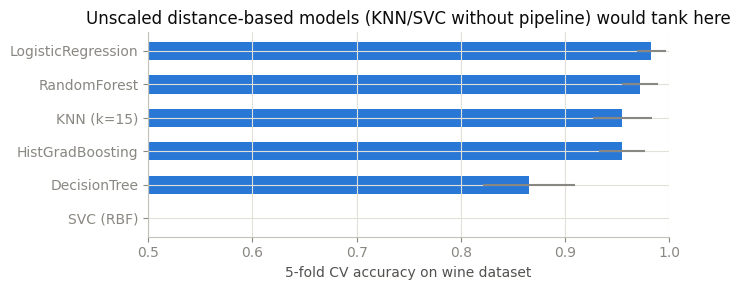

In [21]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(res["model"][::-1], res["mean_acc"][::-1], xerr=res["std"][::-1],
        color=PALETTE[0], height=0.55, error_kw={"ecolor": GRAY})
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("5-fold CV accuracy on wine dataset")
ax.set_title("Unscaled distance-based models (KNN/SVC without pipeline) would tank here")
plt.tight_layout(); plt.show()

<a id="7"></a>
## 7. Regression, regularization & the bias-variance tradeoff

Regression predicts continuous targets. Core linear family:

- `LinearRegression` — ordinary least squares, no regularization.
- `Ridge` (L2) — shrinks all coefficients smoothly toward 0. Default when features are many/correlated.
- `Lasso` (L1) — drives some coefficients to **exactly 0** → built-in feature selection.
- `ElasticNet` — blend of both (`l1_ratio`).

Regularization strength is `alpha` (bigger = more shrinkage). **Always scale features before regularized linear models** — the penalty is scale-sensitive.

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

diab = load_diabetes()
Xr, yr = diab.data, diab.target            # (442, 10), already standardized-ish
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=42)

for mdl in [LinearRegression(), Ridge(alpha=1.0), Lasso(alpha=0.5)]:
    mdl.fit(Xr_tr, yr_tr)
    pred = mdl.predict(Xr_te)
    print(f"{mdl.__class__.__name__:18s} R²={r2_score(yr_te, pred):.3f}  "
          f"MAE={mean_absolute_error(yr_te, pred):6.2f}  "
          f"RMSE={root_mean_squared_error(yr_te, pred):6.2f}  "
          f"zero coefs: {int((mdl.coef_ == 0).sum())}/10")

LinearRegression   R²=0.485  MAE= 41.55  RMSE= 53.37  zero coefs: 0/10
Ridge              R²=0.438  MAE= 45.91  RMSE= 55.73  zero coefs: 0/10
Lasso              R²=0.477  MAE= 43.81  RMSE= 53.80  zero coefs: 6/10


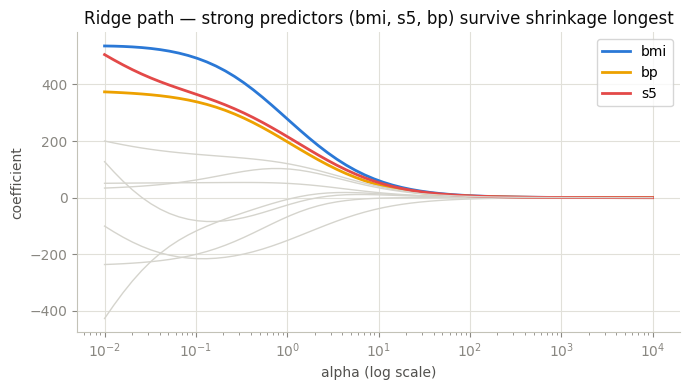

In [23]:
# Watch coefficients shrink as alpha grows (the regularization path)
alphas = np.logspace(-2, 4, 60)
coefs = np.array([Ridge(alpha=a).fit(Xr_tr, yr_tr).coef_ for a in alphas])

highlight = {"bmi": PALETTE[0], "s5": PALETTE[5], "bp": PALETTE[2]}
fig, ax = plt.subplots(figsize=(7, 4))
for j, fname in enumerate(diab.feature_names):
    if fname in highlight:
        ax.plot(alphas, coefs[:, j], color=highlight[fname], linewidth=2, label=fname)
    else:
        ax.plot(alphas, coefs[:, j], color="#d5d4cd", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)"); ax.set_ylabel("coefficient")
ax.set_title("Ridge path — strong predictors (bmi, s5, bp) survive shrinkage longest")
ax.legend()
plt.tight_layout(); plt.show()

### Underfitting vs overfitting, made visible

The **bias–variance tradeoff** in one picture: fit polynomials of increasing degree to noisy samples of a sine wave. Too simple = misses the pattern (high bias). Too flexible = memorizes the noise (high variance). All of ML is walking this ridge.

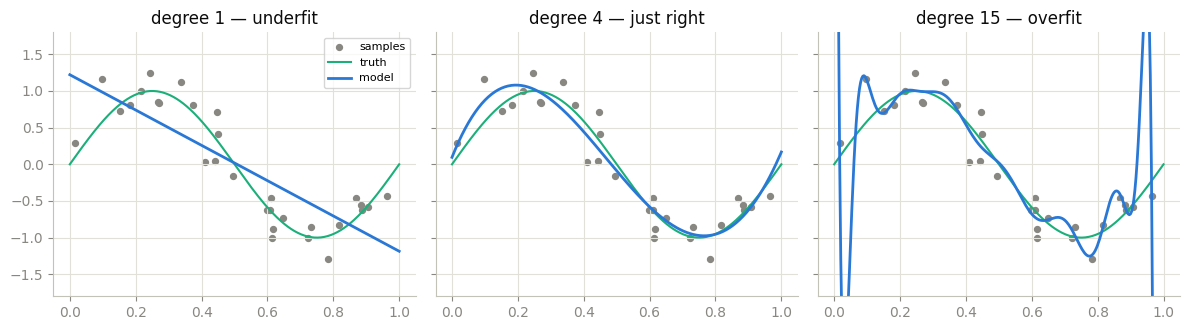

In [24]:
x1d = np.sort(rng.uniform(0, 1, 30))
y1d = np.sin(2 * np.pi * x1d) + rng.normal(0, 0.25, 30)
grid = np.linspace(0, 1, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, deg in zip(axes, [1, 4, 15]):
    pf = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pf.fit(x1d.reshape(-1, 1), y1d)
    ax.scatter(x1d, y1d, s=18, color=GRAY, label="samples")
    ax.plot(grid, np.sin(2 * np.pi * grid), color=PALETTE[1], linewidth=1.5,
            label="truth")
    ax.plot(grid, pf.predict(grid), color=PALETTE[0], linewidth=2, label="model")
    ax.set_ylim(-1.8, 1.8)
    ax.set_title(f"degree {deg} — " + ["underfit", "just right", "overfit"][[1,4,15].index(deg)])
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [25]:
# For real tabular regression, gradient boosting is again the strong default:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(random_state=42).fit(Xr_tr, yr_tr)
print("HistGB R²:", round(r2_score(yr_te, hgb.predict(Xr_te)), 3),
      " (diabetes is small & noisy — linear models compete well here)")

HistGB R²: 0.393  (diabetes is small & noisy — linear models compete well here)


<a id="8"></a>
## 8. Model evaluation beyond accuracy

**Accuracy lies when classes are imbalanced.** A 99%-negative dataset gives a do-nothing model 99% accuracy. The tools that don't lie:

- **Confusion matrix** — the full picture of what got confused with what.
- **Precision** = of my positive predictions, how many were right? (cost of false alarms)
- **Recall** = of the true positives, how many did I find? (cost of misses)
- **F1** — harmonic mean of both.
- **ROC-AUC** — ranking quality across all thresholds; **PR curve** — better view under heavy imbalance.

Always ask: *which error is expensive in my application?* A cancer screen wants recall; a spam filter wants precision.

In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(Xc_train, yc_train)

# ALWAYS compare against a dumb baseline first:
dummy = DummyClassifier(strategy="most_frequent").fit(Xc_train, yc_train)
print("dummy accuracy :", round(dummy.score(Xc_test, yc_test), 3))
print("model accuracy :", round(logreg.score(Xc_test, yc_test), 3))
print()
print(classification_report(yc_test, logreg.predict(Xc_test),
                            target_names=cancer.target_names))

dummy accuracy : 0.629
model accuracy : 0.986

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



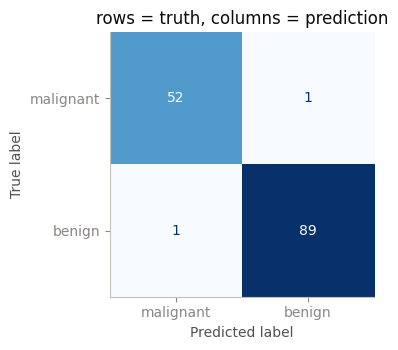

In [27]:
fig, ax = plt.subplots(figsize=(4.2, 3.6))
ConfusionMatrixDisplay.from_estimator(logreg, Xc_test, yc_test,
                                      display_labels=cancer.target_names,
                                      cmap="Blues", ax=ax, colorbar=False)
ax.set_title("rows = truth, columns = prediction")
ax.grid(False)
plt.tight_layout(); plt.show()

C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


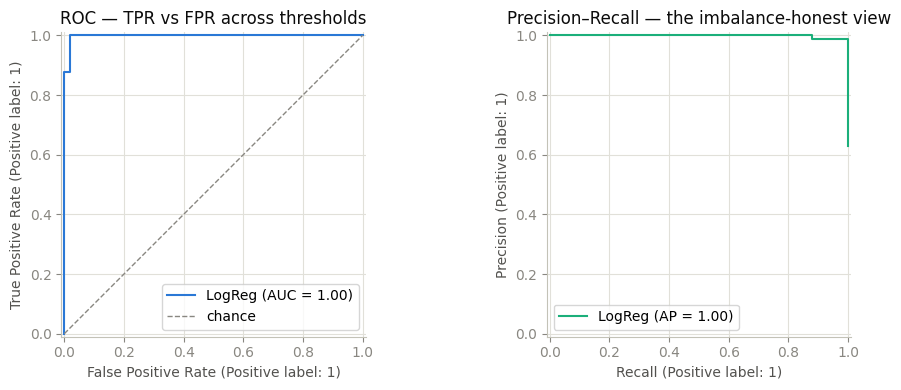

In [28]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_estimator(logreg, Xc_test, yc_test, ax=axes[0],
                               color=PALETTE[0], name="LogReg")
axes[0].plot([0, 1], [0, 1], "--", color=GRAY, linewidth=1, label="chance")
axes[0].legend(); axes[0].set_title("ROC — TPR vs FPR across thresholds")
PrecisionRecallDisplay.from_estimator(logreg, Xc_test, yc_test, ax=axes[1],
                                      color=PALETTE[1], name="LogReg")
axes[1].set_title("Precision–Recall — the imbalance-honest view")
plt.tight_layout(); plt.show()

**Regression metrics** (from §7): $R^2$ (`score` default; 1 = perfect, 0 = predicting the mean, can go negative), `MAE` (robust, in target units), `RMSE` (punishes big errors). Also `mean_absolute_percentage_error` for relative errors — beware targets near zero.

<a id="9"></a>
## 9. Cross-validation

A single train/test split gives one noisy estimate. **k-fold CV** trains k models, each holding out a different 1/k of the data, and reports the score distribution — a far more trustworthy estimate, especially on small data.

- `cross_val_score` — quick, one metric.
- `cross_validate` — multiple metrics + timings + train scores (reveals overfitting).
- `StratifiedKFold` is used automatically for classifiers; use `KFold(shuffle=True)` for regression; `GroupKFold` when rows share an entity (same patient!) that must not straddle folds; `TimeSeriesSplit` for temporal data — never shuffle time.

**Critical:** pass the *pipeline* to CV, never pre-transformed data — otherwise preprocessing leaks across folds.

In [29]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
res = cross_validate(make_pipeline(StandardScaler(), SVC()), Xc, yc, cv=cv,
                     scoring=["accuracy", "precision", "recall", "f1"],
                     return_train_score=True)
summary = pd.DataFrame(res).mean().round(3)
summary

fit_time           0.032
score_time         0.062
test_accuracy      0.977
train_accuracy     0.986
test_precision     0.976
train_precision    0.979
test_recall        0.989
train_recall       0.999
test_f1            0.982
train_f1           0.989
dtype: float64

In [30]:
# train vs test gap is your overfitting gauge:
gap = summary["train_accuracy"] - summary["test_accuracy"]
print(f"train acc {summary['train_accuracy']:.3f} vs CV acc {summary['test_accuracy']:.3f}"
      f"  -> gap {gap:.3f} (small gap = healthy)")

train acc 0.986 vs CV acc 0.977  -> gap 0.009 (small gap = healthy)


<a id="10"></a>
## 10. Hyperparameter tuning: Grid, Random, Halving

Hyperparameters (`C`, `gamma`, `max_depth`, …) are *chosen*, not learned. The searchers wrap any estimator and are themselves estimators (`fit` runs the search, then refits the best config on all data):

- **`GridSearchCV`** — exhaustive over a small grid.
- **`RandomizedSearchCV`** — samples `n_iter` configs from distributions; almost always better value for >2 hyperparameters.
- **`HalvingGridSearchCV`** — successive halving: audition everything cheaply on little data, promote survivors to more data. Big speedups on big grids.

The double-underscore syntax reaches inside pipelines: `stepname__param`.

In [31]:
from sklearn.model_selection import GridSearchCV

pipe_svc = make_pipeline(StandardScaler(), SVC())
param_grid = {"svc__C":     [0.1, 1, 10, 100],
              "svc__gamma": [0.001, 0.01, 0.1, 1]}

gs = GridSearchCV(pipe_svc, param_grid, cv=5, n_jobs=-1)
gs.fit(Xc_train, yc_train)         # search uses ONLY training data
print("best params:", gs.best_params_)
print("best CV score:", round(gs.best_score_, 3))
print("held-out test:", round(gs.score(Xc_test, yc_test), 3))  # gs is now the refit best model

best params: {'svc__C': 10, 'svc__gamma': 0.001}
best CV score: 0.977
held-out test: 0.979


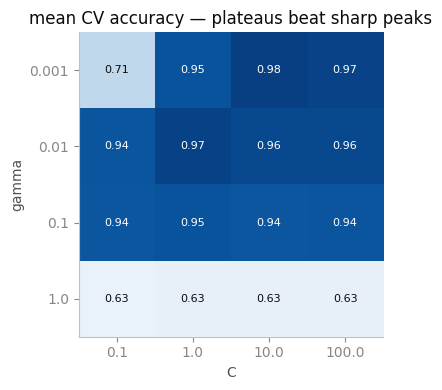

In [32]:
# cv_results_ is a goldmine — turn it into a heatmap to SEE the landscape
cvres = pd.DataFrame(gs.cv_results_)
heat = cvres.pivot_table(index="param_svc__gamma", columns="param_svc__C",
                         values="mean_test_score")
fig, ax = plt.subplots(figsize=(5.5, 4))
im = ax.imshow(heat.values, cmap="Blues", vmin=0.6, vmax=1.0)
ax.set_xticks(range(len(heat.columns)), heat.columns)
ax.set_yticks(range(len(heat.index)), heat.index)
ax.set_xlabel("C"); ax.set_ylabel("gamma")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if v > 0.9 else "#0b0b0b")
ax.set_title("mean CV accuracy — plateaus beat sharp peaks")
ax.grid(False)
plt.tight_layout(); plt.show()

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions={
        "n_estimators": randint(50, 300),
        "max_depth": [None, 5, 10, 20],
        "min_samples_leaf": randint(1, 10),
        "max_features": loguniform(0.1, 1.0),
    },
    n_iter=15, cv=3, random_state=42, n_jobs=-1)
rs.fit(Xc_train, yc_train)
print("best:", rs.best_params_)
print("CV score:", round(rs.best_score_, 3), "| test:", round(rs.score(Xc_test, yc_test), 3))

best: {'max_depth': None, 'max_features': np.float64(0.1432249371823025), 'min_samples_leaf': 3, 'n_estimators': 264}
CV score: 0.96 | test: 0.958


In [34]:
# Successive halving (experimental import flag required)
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV

hs = HalvingGridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    {"learning_rate": [0.03, 0.1, 0.3], "max_depth": [2, 3, None]},
    cv=3, factor=3, random_state=42)
hs.fit(Xc_train, yc_train)
print("best:", hs.best_params_, "| test:", round(hs.score(Xc_test, yc_test), 3))

best: {'learning_rate': 0.3, 'max_depth': None} | test: 0.965


**Expert notes on tuning hygiene**

- The CV score of the *best* config is optimistically biased (you picked the max of many noisy numbers). For an honest estimate of the whole tuning procedure, use **nested CV**: `cross_val_score(GridSearchCV(...), X, y)`.
- `scoring=` accepts any metric string (`"f1"`, `"roc_auc"`, `"neg_mean_absolute_error"` — error metrics are negated so bigger is always better) or a custom `make_scorer`.
- Prefer `RandomizedSearchCV` with wide `loguniform` ranges first; refine with a small grid after you see the landscape.

<a id="11"></a>
## 11. Ensembles: Voting, Bagging, Stacking

Combining diverse models reduces variance (and sometimes bias):

- **Voting** — average predictions (`voting="soft"` averages probabilities; usually better).
- **Bagging** — many copies of one model on bootstrap samples (`RandomForest` = bagged trees + random feature subsets).
- **Boosting** — models built *sequentially*, each fixing the last one's mistakes (`HistGradientBoosting*`, and outside sklearn: XGBoost/LightGBM).
- **Stacking** — a meta-model learns how to *weigh* base models, trained on their out-of-fold predictions (leak-free by construction).

In [35]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

base = [("lr",  make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
        ("rf",  RandomForestClassifier(n_estimators=100, random_state=42)),
        ("nb",  GaussianNB())]

voting   = VotingClassifier(base, voting="soft")
stacking = StackingClassifier(base, final_estimator=LogisticRegression(max_iter=1000), cv=5)

for name, clf in [("LogReg alone", base[0][1]), ("RandomForest alone", base[1][1]),
                  ("Soft voting", voting), ("Stacking", stacking)]:
    scores = cross_val_score(clf, Xc, yc, cv=5)
    print(f"{name:20s} {scores.mean():.3f} ± {scores.std():.3f}")

LogReg alone         0.981 ± 0.007


RandomForest alone   0.956 ± 0.023


Soft voting          0.953 ± 0.018


Stacking             0.979 ± 0.007


On small clean datasets the gains are modest; on messy real data stacking often adds a solid point or two. **Diversity is the fuel** — stacking three tuned copies of the same model buys nothing.

<a id="12"></a>
## 12. Clustering (unsupervised: no `y`)

| Algorithm | Assumes | Must specify k? | Kills it on |
|---|---|---|---|
| `KMeans` | round, similar-size clusters | yes | compact blobs |
| `DBSCAN` | density = cluster | no (needs `eps`) | arbitrary shapes, finds noise |
| `AgglomerativeClustering` | hierarchy | yes (or distance threshold) | dendrogram insight |
| `GaussianMixture` | ellipsoidal Gaussians | yes (BIC can choose) | soft membership probabilities |

**Scale features first** — every one of these is distance-based. Choosing k: the **elbow** (inertia) is a hint; the **silhouette score** (-1…1, higher better) is a sharper criterion.

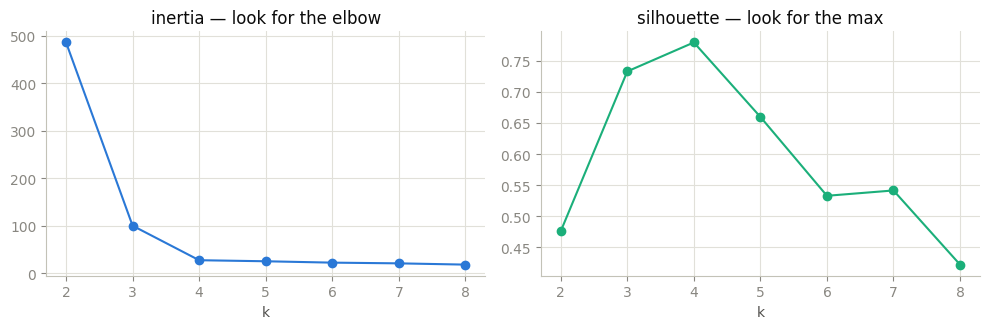

both point at k = 4 (which is how the blobs were made)


In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Xb_s = StandardScaler().fit_transform(X_blobs)
ks = range(2, 9)
inertias = [KMeans(n_clusters=k, random_state=42, n_init="auto").fit(Xb_s).inertia_
            for k in ks]
sils = [silhouette_score(Xb_s, KMeans(n_clusters=k, random_state=42,
                                      n_init="auto").fit_predict(Xb_s)) for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(list(ks), inertias, marker="o", color=PALETTE[0])
axes[0].set_xlabel("k"); axes[0].set_title("inertia — look for the elbow")
axes[1].plot(list(ks), sils, marker="o", color=PALETTE[1])
axes[1].set_xlabel("k"); axes[1].set_title("silhouette — look for the max")
plt.tight_layout(); plt.show()
print("both point at k = 4 (which is how the blobs were made)")

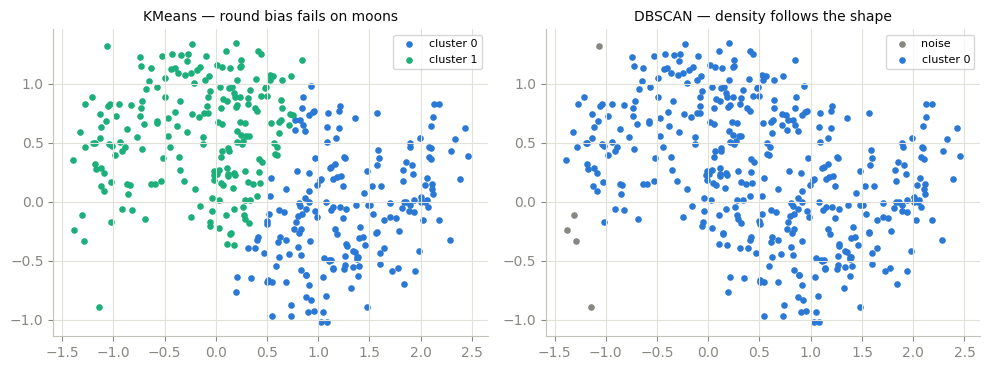

In [37]:
from sklearn.cluster import DBSCAN

km_labels = KMeans(n_clusters=2, random_state=42, n_init="auto").fit_predict(X_moons)
db_labels = DBSCAN(eps=0.25, min_samples=5).fit_predict(X_moons)   # -1 = noise

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, labels, title in [(axes[0], km_labels, "KMeans — round bias fails on moons"),
                          (axes[1], db_labels, "DBSCAN — density follows the shape")]:
    for lab in np.unique(labels):
        m = labels == lab
        color = GRAY if lab == -1 else PALETTE[lab % len(PALETTE)]
        name = "noise" if lab == -1 else f"cluster {lab}"
        ax.scatter(X_moons[m, 0], X_moons[m, 1], s=14, color=color, label=name)
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

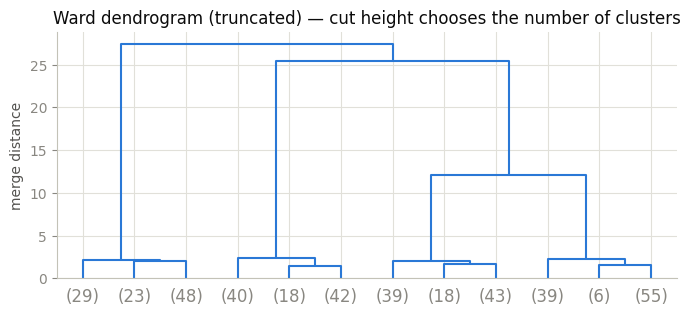

In [38]:
# Hierarchical clustering + dendrogram (scipy draws it)
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(Xb_s, method="ward")
plt.figure(figsize=(8, 3.2))
dendrogram(Z, truncate_mode="lastp", p=12, color_threshold=0, above_threshold_color=PALETTE[0])
plt.title("Ward dendrogram (truncated) — cut height chooses the number of clusters")
plt.ylabel("merge distance")
plt.show()

In [39]:
# GaussianMixture: soft clustering + principled model selection via BIC
from sklearn.mixture import GaussianMixture

bics = [GaussianMixture(n_components=k, random_state=42).fit(Xb_s).bic(Xb_s)
        for k in ks]
print("BIC by k:", dict(zip(ks, np.round(bics))))
print("BIC minimum at k =", list(ks)[int(np.argmin(bics))])

gmm = GaussianMixture(n_components=4, random_state=42).fit(Xb_s)
print("\nsoft memberships of first 3 points:\n", gmm.predict_proba(Xb_s[:3]).round(3))

BIC by k: {2: np.float64(1782.0), 3: np.float64(981.0), 4: np.float64(806.0), 5: np.float64(837.0), 6: np.float64(870.0), 7: np.float64(895.0), 8: np.float64(924.0)}
BIC minimum at k = 4

soft memberships of first 3 points:
 [[0.    1.    0.    0.   ]
 [0.    0.008 0.    0.992]
 [0.    1.    0.    0.   ]]


**Gotcha:** cluster labels are arbitrary integers — "cluster 0" this run may be "cluster 2" next run. Never compare label values across runs; compare *partitions* (`adjusted_rand_score`).

<a id="13"></a>
## 13. Dimensionality reduction: PCA & t-SNE

- **PCA** finds orthogonal directions of maximal variance. Linear, fast, invertible, great for compression, decorrelation, noise reduction, and as a preprocessing step. *Scale first* unless features share units.
- **t-SNE / UMAP** are nonlinear and for **visualization only** — they have no `transform` for new data (t-SNE), and distances/densities between far-apart groups in the embedding are not meaningful.

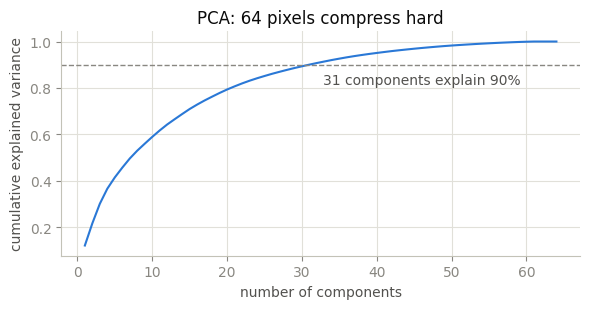

In [40]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()                       # 1797 samples, 64 pixel features
Xg = StandardScaler().fit_transform(digits.data)

pca_full = PCA().fit(Xg)
cum = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.arange(1, 65), cum, color=PALETTE[0])
ax.axhline(0.90, color=GRAY, linestyle="--", linewidth=1)
k90 = int(np.argmax(cum >= 0.90) + 1)
ax.annotate(f"{k90} components explain 90%", (k90, 0.90), textcoords="offset points",
            xytext=(10, -14), color="#52514e")
ax.set_xlabel("number of components"); ax.set_ylabel("cumulative explained variance")
ax.set_title("PCA: 64 pixels compress hard")
plt.tight_layout(); plt.show()

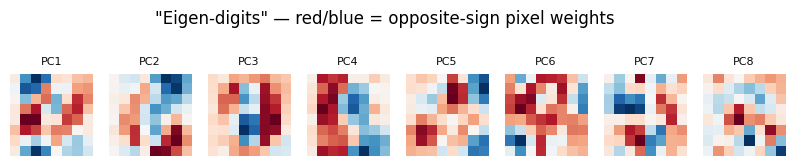

In [41]:
# Components are directions in pixel space — for images, you can look at them
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for i, ax in enumerate(axes):
    ax.imshow(pca_full.components_[i].reshape(8, 8), cmap="RdBu")  # diverging: sign matters
    ax.set_title(f"PC{i+1}", fontsize=8); ax.axis("off")
plt.suptitle('"Eigen-digits" — red/blue = opposite-sign pixel weights', y=1.15)
plt.show()

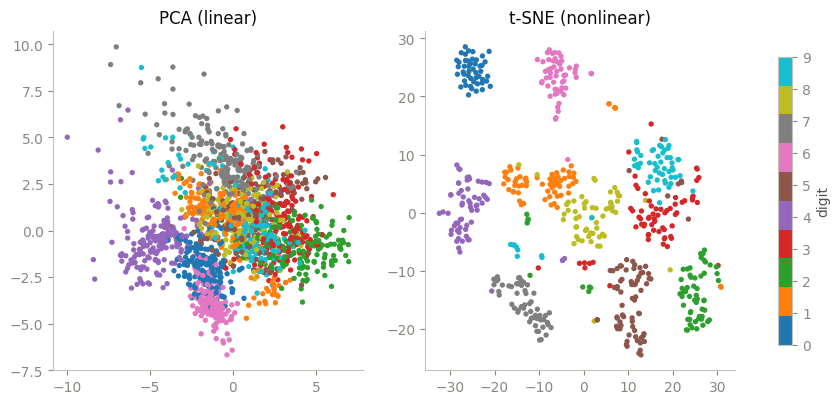

In [42]:
from sklearn.manifold import TSNE

X2_pca = PCA(n_components=2, random_state=42).fit_transform(Xg)
sub = rng.choice(len(Xg), 600, replace=False)               # t-SNE is O(n²)-ish: subsample
X2_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(Xg[sub])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, X2, yy, title in [(axes[0], X2_pca, digits.target, "PCA (linear)"),
                          (axes[1], X2_tsne, digits.target[sub], "t-SNE (nonlinear)")]:
    sc = ax.scatter(X2[:, 0], X2[:, 1], c=yy, cmap="tab10", s=8)
    ax.set_title(title); ax.grid(False)
fig.colorbar(sc, ax=axes, ticks=range(10), label="digit", shrink=0.85)
plt.show()

PCA preserves global variance but smears the classes; t-SNE untangles local neighborhoods into clean islands. Use t-SNE to *look*, PCA (or `TruncatedSVD` for sparse data) to *feed models*.

<a id="14"></a>
## 14. Feature selection & importance — and the leakage trap

Why select features? Speed, interpretability, and less overfitting on wide data. The ladder, cheap to expensive:

1. `VarianceThreshold` — drop (near-)constant columns.
2. `SelectKBest` — univariate stats per feature (fast, ignores interactions).
3. `RFE` / `SelectFromModel` — let a model rank features.
4. **`permutation_importance`** — shuffle one column, measure the score drop. Model-agnostic, computed on *held-out* data. **Trust this over `feature_importances_`**, which is biased toward high-cardinality features and reflects training data.

In [43]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE

skb = SelectKBest(f_classif, k=5).fit(Xc_train, yc_train)
rfe = RFE(LogisticRegression(max_iter=5000), n_features_to_select=5).fit(
    StandardScaler().fit_transform(Xc_train), yc_train)

print("SelectKBest top-5:", list(Xc.columns[skb.get_support()]))
print("RFE top-5       :", list(Xc.columns[rfe.get_support()]))

SelectKBest top-5: ['mean perimeter', 'mean concave points', 'worst radius', 'worst perimeter', 'worst concave points']
RFE top-5       : ['radius error', 'worst radius', 'worst texture', 'worst area', 'worst concave points']


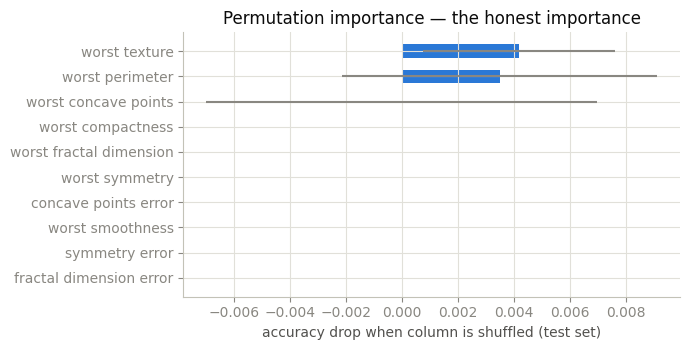

In [44]:
from sklearn.inspection import permutation_importance

rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xc_train, yc_train)
pi = permutation_importance(rf, Xc_test, yc_test, n_repeats=10, random_state=42)

order = pi.importances_mean.argsort()[-10:]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(Xc.columns[order], pi.importances_mean[order],
        xerr=pi.importances_std[order], color=PALETTE[0], height=0.55,
        error_kw={"ecolor": GRAY})
ax.set_xlabel("accuracy drop when column is shuffled (test set)")
ax.set_title("Permutation importance — the honest importance")
plt.tight_layout(); plt.show()

### The leakage trap, demonstrated

Now the most instructive experiment in this notebook. Take **pure noise**: 100 samples, 1000 random features, random labels. True accuracy of anything is 50%. Select the 10 "best" features **before** cross-validation — and watch CV swear the model works.

In [45]:
X_noise = rng.normal(size=(100, 1000))
y_noise = rng.integers(0, 2, 100)

# WRONG: selector sees ALL rows (including future CV test rows) before the split
X_cheat = SelectKBest(f_classif, k=10).fit_transform(X_noise, y_noise)
wrong = cross_val_score(LogisticRegression(), X_cheat, y_noise, cv=5).mean()

# RIGHT: selection lives inside the pipeline, so it's refit per training fold
honest_pipe = make_pipeline(SelectKBest(f_classif, k=10), LogisticRegression())
right = cross_val_score(honest_pipe, X_noise, y_noise, cv=5).mean()

print(f"LEAKY  pipeline CV accuracy: {wrong:.2f}   <- confident lie on pure noise!")
print(f"HONEST pipeline CV accuracy: {right:.2f}   <- coin flip, the truth")

LEAKY  pipeline CV accuracy: 0.77   <- confident lie on pure noise!
HONEST pipeline CV accuracy: 0.54   <- coin flip, the truth


The leaky version cherry-picked columns that correlate with the labels *by chance across the whole dataset* — including the rows later used as "test" folds. This exact bug ships in real papers and real products. **The fix is always the same: every data-dependent step goes inside the pipeline.**

<a id="15"></a>
## 15. Text features

Classical text ML = **bag of words**: count token occurrences per document, one column per vocabulary word (a sparse matrix).

- `CountVectorizer` — raw counts; `ngram_range=(1,2)` adds bigrams ("not good" ≠ "good").
- `TfidfVectorizer` — counts reweighted so words common in *every* document (the, and) fade, distinctive words pop. Usually the better default.

Vectorizers are transformers, so they slot straight into pipelines — and the vocabulary is fitted on training folds only (no leakage).

In [46]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

docs = ["the movie was great and moving",
        "great plot and a great cast",
        "the film was dull and far too long",
        "boring plot, awful pacing, terrible film"]
cv_txt = CountVectorizer()
bow = cv_txt.fit_transform(docs)                 # sparse (4 docs × vocab)
print("vocabulary:", cv_txt.get_feature_names_out())
pd.DataFrame(bow.toarray(), columns=cv_txt.get_feature_names_out(),
             index=[f"doc{i}" for i in range(4)])

vocabulary: ['and' 'awful' 'boring' 'cast' 'dull' 'far' 'film' 'great' 'long' 'movie'
 'moving' 'pacing' 'plot' 'terrible' 'the' 'too' 'was']


,and,awful,boring,cast,dull,far,film,great,long,movie,moving,pacing,plot,terrible,the,too,was
doc0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,1
doc1,1,0,0,1,0,0,0,2,0,0,0,0,1,0,0,0,0
doc2,1,0,0,0,1,1,1,0,1,0,0,0,0,0,1,1,1
doc3,0,1,1,0,0,0,1,0,0,0,0,1,1,1,0,0,0


In [47]:
corpus = [
    ("an absolute delight from start to finish", 1),
    ("brilliant acting and a moving story", 1),
    ("i loved every minute of it", 1),
    ("funny, warm and beautifully shot", 1),
    ("a masterpiece, instantly rewatchable", 1),
    ("clever script with a satisfying ending", 1),
    ("great soundtrack and stunning visuals", 1),
    ("charming characters you root for", 1),
    ("a total waste of two hours", 0),
    ("boring, predictable and far too long", 0),
    ("the acting was wooden and the plot absurd", 0),
    ("i walked out halfway, dreadful", 0),
    ("awful pacing and a lazy script", 0),
    ("painfully dull with no redeeming qualities", 0),
    ("terrible dialogue, cardboard characters", 0),
    ("a mess of clichés and plot holes", 0),
]
texts = [t for t, _ in corpus]; labels = [l for _, l in corpus]

text_clf = make_pipeline(TfidfVectorizer(ngram_range=(1, 2)),
                         LogisticRegression(max_iter=1000))
text_clf.fit(texts, labels)
for s in ["what a delight, loved the story", "predictable and dreadful, so boring"]:
    p = text_clf.predict_proba([s])[0, 1]
    print(f"P(positive) = {p:.2f}  <- {s!r}")

P(positive) = 0.53  <- 'what a delight, loved the story'
P(positive) = 0.44  <- 'predictable and dreadful, so boring'


In [48]:
# Linear model + text = free interpretability: read the learned word weights
vec = text_clf.named_steps["tfidfvectorizer"]
w = text_clf.named_steps["logisticregression"].coef_[0]
top = np.argsort(w)
print("most NEGATIVE words:", list(vec.get_feature_names_out()[top[:5]]))
print("most POSITIVE words:", list(vec.get_feature_names_out()[top[-5:]]))

most NEGATIVE words: ['the', 'plot', 'cardboard', 'cardboard characters', 'terrible dialogue']
most POSITIVE words: ['instantly rewatchable', 'rewatchable', 'instantly', 'masterpiece instantly', 'masterpiece']


With 16 documents this is a toy — but the pipeline is *exactly* what scales to millions of documents (swap in `fetch_20newsgroups`, add `MultinomialNB` for speed). For modern semantic tasks you'd use transformer embeddings as features and still feed them to a scikit-learn classifier on top.

<a id="16"></a>
## 16. Expert: custom transformers & estimators

When built-ins don't cut it, write your own — the contract is tiny:

- **Transformer**: inherit `BaseEstimator, TransformerMixin`, implement `fit` (return `self`) and `transform`. You get `fit_transform`, `get_params`/`set_params` (→ grid-searchable!), and pipeline compatibility for free.
- **Quick one-offs**: `FunctionTransformer(np.log1p)` wraps any stateless function.
- **Estimator**: add `ClassifierMixin`/`RegressorMixin` and implement `predict`. Store everything learned with a trailing underscore, and set `classes_`.

In [49]:
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.preprocessing import FunctionTransformer

# 1) Stateless one-liner:
log_tf = FunctionTransformer(np.log1p)
print(log_tf.fit_transform(np.array([[0.0, 9.0], [99.0, 999.0]])))

[[0.         2.30258509]
 [4.60517019 6.90775528]]


In [50]:
# 2) A real custom transformer: clip each feature to its training-set quantiles
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, low=0.01, high=0.99):    # params go on self, unvalidated (sklearn rule)
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_ = np.quantile(X, self.low, axis=0)    # learned => trailing underscore
        self.hi_ = np.quantile(X, self.high, axis=0)
        return self                                     # fit ALWAYS returns self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lo_, self.hi_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features) if input_features is not None \
               else np.array([f"x{i}" for i in range(len(self.lo_))])

Xout = np.array([[1.0], [2.0], [3.0], [100.0]])   # 100 is an outlier
clip = QuantileClipper(low=0.0, high=0.75)
print(clip.fit_transform(Xout).ravel())
print("grid-searchable params:", clip.get_params())

[ 1.    2.    3.   27.25]
grid-searchable params: {'high': 0.75, 'low': 0.0}


In [51]:
# It composes and cross-validates like any built-in:
robust_pipe = make_pipeline(QuantileClipper(), StandardScaler(),
                            LogisticRegression(max_iter=1000))
print("CV with custom step:", cross_val_score(robust_pipe, Xc, yc, cv=5).mean().round(3))

CV with custom step: 0.982


In [52]:
# 3) A minimal custom classifier (re-implementing DummyClassifier's core)
class MajorityClassifier(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.classes_, counts = np.unique(y, return_counts=True)
        self.majority_ = self.classes_[np.argmax(counts)]
        return self

    def predict(self, X):
        return np.full(len(X), self.majority_)

print("MajorityClassifier CV:", cross_val_score(MajorityClassifier(), Xc, yc, cv=5).mean().round(3))
print("(= the base rate; any real model must beat this)")

MajorityClassifier CV: 0.628
(= the base rate; any real model must beat this)


**Going further:** validate inputs with `sklearn.utils.validation` helpers and run `sklearn.utils.estimator_checks.check_estimator(MyEstimator())` to certify full API compliance (required if you ever publish an estimator).

<a id="17"></a>
## 17. Expert: imbalance, decision thresholds & calibration

Three separate ideas people constantly conflate:

1. **Class imbalance** — the model barely sees the minority class. First aid: `class_weight="balanced"` (reweights the loss). Heavier machinery (SMOTE etc.) lives in the `imbalanced-learn` package.
2. **The decision threshold** — `predict` cuts probabilities at 0.5 by default, which is rarely what your cost structure wants. `TunedThresholdClassifierCV` *learns* the cutoff for your metric.
3. **Calibration** — does "80% confident" actually mean right 80% of the time? Many models (NB, SVM, boosted trees) are over/under-confident. `CalibratedClassifierCV` fixes the probabilities.

In [53]:
X_ib, y_ib = make_classification(n_samples=4000, n_features=12, n_informative=6,
                                 weights=[0.95, 0.05], random_state=42)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_ib, y_ib, test_size=0.3,
                                              random_state=42, stratify=y_ib)
print("class balance:", np.bincount(yi_tr), "-> minority is 5%")

from sklearn.metrics import f1_score, recall_score
plain = LogisticRegression(max_iter=1000).fit(Xi_tr, yi_tr)
weighted = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xi_tr, yi_tr)
for name, m in [("default", plain), ('class_weight="balanced"', weighted)]:
    p = m.predict(Xi_te)
    print(f"{name:26s} recall={recall_score(yi_te, p):.2f}  f1={f1_score(yi_te, p):.2f}  "
          f"accuracy={m.score(Xi_te, yi_te):.2f}")

class balance: [2646  154] -> minority is 5%
default                    recall=0.41  f1=0.52  accuracy=0.96
class_weight="balanced"    recall=0.79  f1=0.40  accuracy=0.87


In [54]:
# Tune the threshold itself for F1 (sklearn >= 1.5)
from sklearn.model_selection import TunedThresholdClassifierCV

tuned = TunedThresholdClassifierCV(LogisticRegression(max_iter=1000), scoring="f1", cv=5)
tuned.fit(Xi_tr, yi_tr)
print(f"learned threshold: {tuned.best_threshold_:.2f}  (instead of 0.50)")
print(f"tuned-threshold F1 on test: {f1_score(yi_te, tuned.predict(Xi_te)):.2f}")

learned threshold: 0.37  (instead of 0.50)
tuned-threshold F1 on test: 0.58


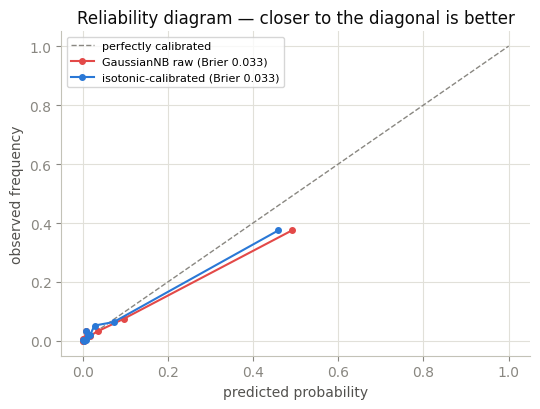

In [55]:
# Calibration: GaussianNB is famously overconfident — measure it, then fix it
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

nb_raw = GaussianNB().fit(Xi_tr, yi_tr)
nb_cal = CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5).fit(Xi_tr, yi_tr)

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.plot([0, 1], [0, 1], "--", color=GRAY, linewidth=1, label="perfectly calibrated")
for mdl, name, color in [(nb_raw, "GaussianNB raw", PALETTE[5]),
                         (nb_cal, "isotonic-calibrated", PALETTE[0])]:
    prob = mdl.predict_proba(Xi_te)[:, 1]
    frac, mean_pred = calibration_curve(yi_te, prob, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac, marker="o", markersize=4, color=color,
            label=f"{name} (Brier {brier_score_loss(yi_te, prob):.3f})")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Reliability diagram — closer to the diagonal is better")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

If downstream decisions consume the *probabilities* (pricing, ranking, medical triage), calibration matters as much as accuracy. Brier score is the go-to single number (lower = better).

<a id="18"></a>
## 18. Expert: learning & validation curves — diagnose before you tune

Two questions decide what to do next, and each has a curve:

- **"Would more data help?"** → `learning_curve`. If train and validation scores have *converged*, more data won't help — you need a richer model. If a gap remains, more data (or regularization) will.
- **"Is this hyperparameter under- or over-fitting?"** → `validation_curve`, one hyperparameter swept across a range.

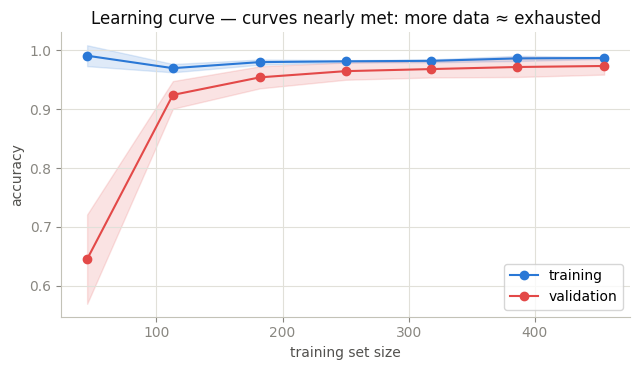

In [56]:
from sklearn.model_selection import learning_curve

sizes, tr_sc, va_sc = learning_curve(
    make_pipeline(StandardScaler(), SVC()), Xc, yc,
    train_sizes=np.linspace(0.1, 1.0, 7), cv=5, n_jobs=-1)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for sc, name, color in [(tr_sc, "training", PALETTE[0]), (va_sc, "validation", PALETTE[5])]:
    ax.plot(sizes, sc.mean(axis=1), marker="o", color=color, label=name)
    ax.fill_between(sizes, sc.mean(1) - sc.std(1), sc.mean(1) + sc.std(1),
                    alpha=0.15, color=color)
ax.set_xlabel("training set size"); ax.set_ylabel("accuracy")
ax.set_title("Learning curve — curves nearly met: more data ≈ exhausted")
ax.legend()
plt.tight_layout(); plt.show()

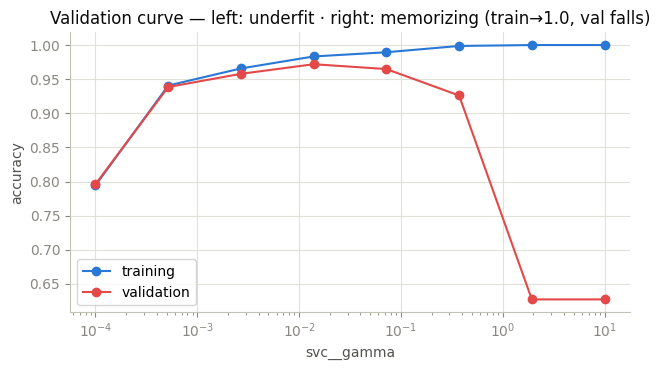

In [57]:
from sklearn.model_selection import validation_curve

gammas = np.logspace(-4, 1, 8)
tr_sc, va_sc = validation_curve(make_pipeline(StandardScaler(), SVC()), Xc, yc,
                                param_name="svc__gamma", param_range=gammas,
                                cv=5, n_jobs=-1)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for sc, name, color in [(tr_sc, "training", PALETTE[0]), (va_sc, "validation", PALETTE[5])]:
    ax.plot(gammas, sc.mean(axis=1), marker="o", color=color, label=name)
ax.set_xscale("log")
ax.set_xlabel("svc__gamma"); ax.set_ylabel("accuracy")
ax.set_title("Validation curve — left: underfit · right: memorizing (train→1.0, val falls)")
ax.legend()
plt.tight_layout(); plt.show()

<a id="19"></a>
## 19. Model persistence & production notes

- Persist the **whole pipeline** (preprocessing + model as one object) with `joblib` — never a bare model that silently expects pre-scaled input.
- **Pin your scikit-learn version.** Loading a pickle across versions warns for a reason: internals change. Ship `sklearn.__version__` alongside the artifact.
- Pickles execute code on load — only load artifacts you trust. For cross-language/portable deployment, export to **ONNX** (`skl2onnx`).
- For huge datasets: models with `partial_fit` (`SGDClassifier`, `MiniBatchKMeans`, …) learn in mini-batches; `warm_start=True` lets ensembles grow incrementally.

In [58]:
import tempfile, os
from joblib import dump, load

with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, "cancer_pipeline.joblib")
    dump(gs.best_estimator_, path)                      # the tuned pipeline from §10
    print(f"artifact size: {os.path.getsize(path)/1024:.1f} KB")
    reloaded = load(path)
    assert (reloaded.predict(Xc_test) == gs.best_estimator_.predict(Xc_test)).all()
    print("reloaded model reproduces predictions exactly ✔")
    print("persist alongside it -> sklearn", sklearn.__version__)

artifact size: 23.3 KB
reloaded model reproduces predictions exactly ✔
persist alongside it -> sklearn 1.7.2


<a id="20"></a>
## 20. Gotchas & cheat sheet

### The gotchas that bite everyone

1. **Leakage** — any `fit` (scaler, selector, vectorizer, imputer) touching test rows inflates scores. *Fix: pipelines, always* (§14 proved it on pure noise).
2. **Accuracy on imbalanced data** — report precision/recall/F1/PR-AUC instead (§8, §17).
3. **Forgetting to scale** before SVM / k-NN / logistic / PCA / k-means (§6 bar chart).
4. **`OrdinalEncoder` on nominal categories** with linear models — invents fake order (§4).
5. **Tuning on the test set** — the test set is spent the moment it influences a decision. Tune with CV on train; touch test once, at the end.
6. **Trusting `feature_importances_`** — prefer permutation importance on held-out data (§14).
7. **`random_state` unset** — results you can't reproduce aren't results.
8. **Comparing cluster label integers across runs** — labels are arbitrary (§12).
9. **Time series with shuffled CV** — the model peeks at the future; use `TimeSeriesSplit`.
10. **Reading t-SNE distances literally** — inter-cluster spacing is meaningless (§13).

### Ten-line mental model of the library

| Need | Reach for |
|---|---|
| baseline | `DummyClassifier` / `DummyRegressor` |
| interpretable model | `LogisticRegression`, `Ridge`, small `DecisionTree` |
| strongest tabular default | `HistGradientBoosting*` |
| robust & low-effort | `RandomForest*` |
| preprocessing skeleton | `Pipeline` + `ColumnTransformer` |
| honest evaluation | `cross_validate` + task-appropriate metric |
| tuning | `RandomizedSearchCV` → refine with `GridSearchCV` |
| clustering | `KMeans` → `DBSCAN` if shapes are weird |
| compression / viz | `PCA` / `TSNE` |
| ship it | `joblib.dump(pipeline)` + version pin |

### Where to go next

- [scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html) — genuinely excellent, read it topic by topic
- [Choosing the right estimator (the famous map)](https://scikit-learn.org/stable/machine_learning_map.html)
- [Common pitfalls page](https://scikit-learn.org/stable/common_pitfalls.html) — official companion to §14/§20
- `imbalanced-learn`, `XGBoost`/`LightGBM`, `skl2onnx` — the ecosystem around the edges

*Companion notebooks in this series: `numpy_basics_to_expert.ipynb`, `opencv_basics_to_expert.ipynb`, `pytorch_basics_to_expert.ipynb`.*